In [1]:
#! Final-evaluation runtime
from google.colab import drive
drive.mount('/content/drive')

import hashlib, json, os, sys

from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Mounted at /content/drive
Device: cuda


In [2]:
#! Bind final evaluation to already-fixed models and thresholds
ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

TASK = ROOT / 'task4'
CODE_DIR = TASK / 'code'
DATA10_DIR = TASK / 'data' / 'cifar10'
DATA100_DIR = TASK / 'data' / 'cifar100'
CORE_FILE = CODE_DIR / 'cifar_osr_core_v1.py'
SCORE_FILE = CODE_DIR / 'cifar_osr_scores_v1.py'

VANILLA_BEST = TASK / 'checkpoints' / 'vanilla' / 'best.pt'
VANILLA_LAST = TASK / 'checkpoints' / 'vanilla' / 'last.pt'
GCSC_BEST = TASK / 'checkpoints' / 'gcsc' / 'best.pt'
GCSC_LAST = TASK / 'checkpoints' / 'gcsc' / 'last.pt'
PROSER_BEST = TASK / 'checkpoints' / 'proser' / 'best.pt'
PROSER_LAST = TASK / 'checkpoints' / 'proser' / 'last.pt'

POSTHOC_DIR = TASK / 'results' / 'posthoc'
VANILLA_THRESHOLDS = POSTHOC_DIR / 'thresholds_95pct_known_validation.json'
MAH_REF = POSTHOC_DIR / 'mahalanobis_reference.npz'
GCSC_THRESHOLD = TASK / 'results' / 'gcsc' / 'mls_threshold_95pct_known_validation.json'
PROSER_CALIBRATION = TASK / 'results' / 'proser' / 'calibration.json'

FINAL_DIR = TASK / 'results' / 'final_evaluation'
CACHE_DIR = TASK / 'cache' / 'final_evaluation'
FIG_DIR = FINAL_DIR / 'figures'

for d in [FINAL_DIR, CACHE_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

required = [CORE_FILE, SCORE_FILE, VANILLA_BEST, VANILLA_LAST, VANILLA_THRESHOLDS,
            MAH_REF, GCSC_BEST, GCSC_LAST, GCSC_THRESHOLD,
            PROSER_BEST, PROSER_LAST, PROSER_CALIBRATION]

missing = [str(p) for p in required if not p.is_file()]

if missing:
    raise FileNotFoundError('Finish Tasks 4A-4D first. Missing:\n' + '\n'.join(missing))

sha256 = lambda p: hashlib.sha256(p.read_bytes()).hexdigest()

VANILLA_SHA, GCSC_SHA, PROSER_SHA = map(sha256, [VANILLA_BEST, GCSC_BEST, PROSER_BEST])
vanilla_last = torch.load(VANILLA_LAST, map_location='cpu', weights_only=False)

gcsc_last = torch.load(GCSC_LAST, map_location='cpu', weights_only=False)
proser_last = torch.load(PROSER_LAST, map_location='cpu', weights_only=False)

if vanilla_last.get('epoch') != 100 or not vanilla_last.get('finished', False): raise RuntimeError('Vanilla incomplete.')
if gcsc_last.get('epoch') != 100 or not gcsc_last.get('finished', False): raise RuntimeError('GCSC incomplete.')
if proser_last.get('epoch') != 50 or not proser_last.get('finished', False): raise RuntimeError('PROSER incomplete.')

vanilla_thr_data = json.loads(VANILLA_THRESHOLDS.read_text())
gcsc_thr_data = json.loads(GCSC_THRESHOLD.read_text())
proser_cal = json.loads(PROSER_CALIBRATION.read_text())

if vanilla_thr_data['best_checkpoint_sha256'] != VANILLA_SHA: raise RuntimeError('Vanilla threshold/checkpoint mismatch.')
if gcsc_thr_data['best_checkpoint_sha256'] != GCSC_SHA: raise RuntimeError('GCSC threshold/checkpoint mismatch.')
if proser_cal['best_checkpoint_sha256'] != PROSER_SHA: raise RuntimeError('PROSER calibration/checkpoint mismatch.')

print('All frozen prerequisites: PASS')


All frozen prerequisites: PASS


In [3]:
#! Reuse exact score formulas from Task 4B
sys.path.insert(0, str(CODE_DIR)) if str(CODE_DIR) not in sys.path else None

from cifar_osr_core_v1 import make_resnet18, evaluation_transform, forward_features_logits
from cifar_osr_scores_v1 import SCORE_NAMES, novelty_scores

with np.load(MAH_REF, allow_pickle=False) as ref:
    class_means = ref['class_means'].copy()
    diagonal_variance = ref['shared_diagonal_variance'].copy()
    if str(ref['best_checkpoint_sha256'].item()) != VANILLA_SHA:
        raise RuntimeError('Mahalanobis reference/checkpoint mismatch.')

VANILLA_TAU = {k: float(vanilla_thr_data['thresholds'][k]) for k in SCORE_NAMES}
GCSC_MLS_TAU = float(gcsc_thr_data['threshold'])
PROSER_MLS_TAU = float(proser_cal['mls_tau_95_validation'])
PROSER_PLACEHOLDER_TAU = float(proser_cal['placeholder_tau_95_validation'])

print('Frozen thresholds loaded.')


Frozen thresholds loaded.


In [4]:
#! Unknown data is accessed only now, after all models/scores/thresholds are fixed
BATCH_SIZE, NUM_WORKERS = 256, 2

transform = evaluation_transform()

known_test = datasets.CIFAR10(root=str(DATA10_DIR), train=False, download=True, transform=transform)
unknown_test = datasets.CIFAR100(root=str(DATA100_DIR), train=False, download=True, transform=transform)

NEAR_CLASSES = ['bus','pickup_truck','motorcycle','tractor','wolf','fox','leopard','camel']
FAR_CLASSES = ['bottle','bowl','chair','clock','keyboard','mushroom','sunflower','wardrobe']

fine_targets = np.asarray(unknown_test.targets, dtype=np.int64)

def group_indices(names):
    ids = [unknown_test.class_to_idx[n] for n in names]
    idx = np.flatnonzero(np.isin(fine_targets, ids)).astype(np.int64)
    counts = {n:int(np.sum(fine_targets[idx] == unknown_test.class_to_idx[n])) for n in names}

    if len(idx) != 800 or any(v != 100 for v in counts.values()):
        raise RuntimeError('Each fixed unknown group must contain 8 classes × 100 test images.')
    return idx, counts

near_idx, near_counts = group_indices(NEAR_CLASSES)
far_idx, far_counts = group_indices(FAR_CLASSES)

known_loader = DataLoader(known_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
near_loader = DataLoader(Subset(unknown_test, near_idx.tolist()), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
far_loader = DataLoader(Subset(unknown_test, far_idx.tolist()), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

manifest = {'near_classes':NEAR_CLASSES,'far_classes':FAR_CLASSES,'near_count':800,'far_count':800,
            'near_class_counts':near_counts,'far_class_counts':far_counts,
            'source':'official CIFAR-100 test partition only'}

(FINAL_DIR/'fixed_cifar100_unknown_groups.json').write_text(json.dumps(manifest, indent=2)+'\n')

print('Known:', len(known_test), '| Near:', len(near_idx), '| Far:', len(far_idx))


100%|██████████| 169M/169M [32:20<00:00, 87.1kB/s]


Known: 10000 | Near: 800 | Far: 800


In [5]:
#! Extract model outputs without any gradient/update
@torch.inference_mode()

def extract_standard(model, loader):
    model.eval(); FEA=[]; LOG=[]; LAB=[]

    for x,y in loader:
        f,z = forward_features_logits(model, x.to(DEVICE, non_blocking=True))
        FEA.append(f.float().cpu().numpy()); LOG.append(z.float().cpu().numpy()); LAB.append(y.numpy())

    return np.concatenate(FEA), np.concatenate(LOG), np.concatenate(LAB)

@torch.inference_mode()

def extract_proser(model, dummy, loader):
    model.eval(); dummy.eval(); FEA=[]; KN=[]; DU=[]; LAB=[]

    for x,y in loader:
        f,k = forward_features_logits(model, x.to(DEVICE, non_blocking=True)); d = dummy(f)
        FEA.append(f.float().cpu().numpy()); KN.append(k.float().cpu().numpy()); DU.append(d.float().cpu().numpy()); LAB.append(y.numpy())

    return np.concatenate(FEA), np.concatenate(KN), np.concatenate(DU), np.concatenate(LAB)

def cache_standard(name, sha, model, loader, n):
    path=CACHE_DIR/f'{name}.npz'

    if path.exists():
        with np.load(path,allow_pickle=False) as a:
            if str(a['checkpoint_sha256'].item())!=sha or a['features'].shape!=(n,512) or a['logits'].shape!=(n,10):
                raise RuntimeError('Stale cache: '+str(path))
            return {k:a[k].copy() for k in a.files}

    f,z,y=extract_standard(model,loader)

    if f.shape!=(n,512) or z.shape!=(n,10) or y.shape!=(n,): raise RuntimeError('Extraction shape failure: '+name)
    tmp=path.with_name(path.name+'.tmp')

    with tmp.open('wb') as h: np.savez_compressed(h,features=f,logits=z,labels=y,checkpoint_sha256=np.array(sha))
    os.replace(tmp,path)

    return {'features':f,'logits':z,'labels':y,'checkpoint_sha256':np.array(sha)}

def cache_proser(name, sha, model, dummy, loader, n):
    path=CACHE_DIR/f'{name}.npz'

    if path.exists():
        with np.load(path,allow_pickle=False) as a:
            if str(a['checkpoint_sha256'].item())!=sha or a['features'].shape!=(n,512) or a['known_logits'].shape!=(n,10) or a['dummy_logits'].shape!=(n,5):
                raise RuntimeError('Stale PROSER cache: '+str(path))
            return {k:a[k].copy() for k in a.files}

    f,k,d,y=extract_proser(model,dummy,loader)

    if f.shape!=(n,512) or k.shape!=(n,10) or d.shape!=(n,5) or y.shape!=(n,): raise RuntimeError('PROSER extraction failure: '+name)
    tmp=path.with_name(path.name+'.tmp')

    with tmp.open('wb') as h: np.savez_compressed(h,features=f,known_logits=k,dummy_logits=d,labels=y,checkpoint_sha256=np.array(sha))

    os.replace(tmp,path)

    return {'features':f,'known_logits':k,'dummy_logits':d,'labels':y,'checkpoint_sha256':np.array(sha)}

vm=make_resnet18(10).to(DEVICE); vm.load_state_dict(torch.load(VANILLA_BEST,map_location='cpu',weights_only=False)['model_state_dict'],strict=True)
gm=make_resnet18(10).to(DEVICE); gm.load_state_dict(torch.load(GCSC_BEST,map_location='cpu',weights_only=False)['model_state_dict'],strict=True)
pm=make_resnet18(10).to(DEVICE); pmeta=torch.load(PROSER_BEST,map_location='cpu',weights_only=False); pm.load_state_dict(pmeta['model_state_dict'],strict=True)

pdmy=nn.Linear(pm.fc.in_features,5).to(DEVICE); pdmy.load_state_dict(pmeta['dummy_state_dict'],strict=True)

vanilla={s:cache_standard('vanilla_'+s,VANILLA_SHA,vm,l,n) for s,l,n in [('known',known_loader,10000),('near',near_loader,800),('far',far_loader,800)]}

gcsc={s:cache_standard('gcsc_'+s,GCSC_SHA,gm,l,n) for s,l,n in [('known',known_loader,10000),('near',near_loader,800),('far',far_loader,800)]}

proser={s:cache_proser('proser_'+s,PROSER_SHA,pm,pdmy,l,n) for s,l,n in [('known',known_loader,10000),('near',near_loader,800),('far',far_loader,800)]}

if not np.array_equal(vanilla['known']['labels'],gcsc['known']['labels']) or not np.array_equal(vanilla['known']['labels'],proser['known']['labels']):
    raise RuntimeError('Known-test ordering mismatch.')

print('Frozen inference: PASS')


Frozen inference: PASS


In [6]:
#! All scores: larger means more novel
vanilla_scores={s:novelty_scores(vanilla[s]['logits'],vanilla[s]['features'],class_means,diagonal_variance) for s in ['known','near','far']}

mls=lambda z:-np.max(np.asarray(z,dtype=np.float64),axis=1)

gcsc_mls={s:mls(gcsc[s]['logits']) for s in ['known','near','far']}
proser_mls={s:mls(proser[s]['known_logits']) for s in ['known','near','far']}

def placeholder_score(k,d):
    bias=float(proser_cal['calibration_bias']); T=float(proser_cal['placeholder_temperature'])

    md=np.max(np.asarray(d,dtype=np.float64),axis=1)+bias; k=np.asarray(k,dtype=np.float64)
    a=np.concatenate([k,md[:,None]],axis=1)/T; a-=a.max(axis=1,keepdims=True)
    p=np.exp(a); p/=p.sum(axis=1,keepdims=True)

    return p[:,-1]-p[:,:-1].max(axis=1)

proser_placeholder={s:placeholder_score(proser[s]['known_logits'],proser[s]['dummy_logits']) for s in ['known','near','far']}

def auc(known,unknown):
    y=np.r_[np.zeros(len(known),dtype=int),np.ones(len(unknown),dtype=int)]; sc=np.r_[known,unknown]
    return float(roc_auc_score(y,sc))

def metrics(k,n,f,tau):
    a=np.r_[n,f]
    return {'near_AUROC':auc(k,n),'far_AUROC':auc(k,f),'all_unknown_AUROC':auc(k,a),'threshold':float(tau),
            'known_test_acceptance':float(np.mean(k<=tau)),'near_rejection':float(np.mean(n>tau)),'far_rejection':float(np.mean(f>tau)),
            'all_unknown_rejection':float(np.mean(a>tau)),'near_FPR95TPR':float(np.mean(n<=tau)),'far_FPR95TPR':float(np.mean(f<=tau)),
            'all_unknown_FPR95TPR':float(np.mean(a<=tau))}
print('Scores + metrics ready.')


Scores + metrics ready.


In [7]:
#! Same frozen Vanilla model, same examples, frozen Task 4B thresholds
rows=[]

for name in SCORE_NAMES:
    rows.append({'score':name,**metrics(vanilla_scores['known'][name],vanilla_scores['near'][name],vanilla_scores['far'][name],VANILLA_TAU[name])})
posthoc_table=pd.DataFrame(rows); posthoc_table.to_csv(FINAL_DIR/'table1_vanilla_posthoc_scores.csv',index=False); display(posthoc_table.round(4))

names=list(SCORE_NAMES); M=np.column_stack([np.r_[vanilla_scores['near'][n],vanilla_scores['far'][n]] for n in names]); C=np.zeros((len(names),len(names)))

for i in range(len(names)):
    for j in range(len(names)): C[i,j]=spearmanr(M[:,i],M[:,j]).statistic

corr=pd.DataFrame(C,index=names,columns=names); corr.to_csv(FINAL_DIR/'vanilla_score_spearman_unknowns.csv'); display(corr.round(3))


,score,near_AUROC,far_AUROC,all_unknown_AUROC,threshold,known_test_acceptance,near_rejection,far_rejection,all_unknown_rejection,near_FPR95TPR,far_FPR95TPR,all_unknown_FPR95TPR
0,MSP,0.8226,0.8899,0.8563,0.1414,0.9431,0.2975,0.4438,0.3706,0.7025,0.5562,0.6294
1,MLS,0.8088,0.8864,0.8476,-6.0102,0.9450,0.3338,0.5562,0.4450,0.6662,0.4438,0.5550
2,Energy,0.8091,0.8874,0.8482,-6.1671,0.9457,0.3400,0.5512,0.4456,0.6600,0.4488,0.5544
3,Mahalanobis,0.8056,0.9162,0.8609,3054.6264,0.9496,0.2712,0.4738,0.3725,0.7288,0.5262,0.6275


,MSP,MLS,Energy,Mahalanobis
MSP,1.000,0.932,0.906,0.930
MLS,0.932,1.000,0.997,0.859
Energy,0.906,0.997,1.000,0.837
Mahalanobis,0.930,0.859,0.837,1.000


In [8]:
#! CSA uses only the ten known-class logits

labels=vanilla['known']['labels']; csa=lambda z:float(np.mean(np.asarray(z).argmax(1)==labels))

rows=[]

rows.append({'model':'Vanilla','score':'MLS','CSA':csa(vanilla['known']['logits']),**metrics(vanilla_scores['known']['MLS'],vanilla_scores['near']['MLS'],vanilla_scores['far']['MLS'],VANILLA_TAU['MLS'])})
rows.append({'model':'GCSC','score':'MLS','CSA':csa(gcsc['known']['logits']),**metrics(gcsc_mls['known'],gcsc_mls['near'],gcsc_mls['far'],GCSC_MLS_TAU)})
rows.append({'model':'PROSER','score':'MLS','CSA':csa(proser['known']['known_logits']),**metrics(proser_mls['known'],proser_mls['near'],proser_mls['far'],PROSER_MLS_TAU)})
rows.append({'model':'PROSER','score':'Placeholder','CSA':csa(proser['known']['known_logits']),**metrics(proser_placeholder['known'],proser_placeholder['near'],proser_placeholder['far'],PROSER_PLACEHOLDER_TAU)})

model_table=pd.DataFrame(rows); model_table.to_csv(FINAL_DIR/'table2_trained_model_comparison.csv',index=False); display(model_table.round(4))


,model,score,CSA,near_AUROC,far_AUROC,all_unknown_AUROC,threshold,known_test_acceptance,near_rejection,far_rejection,all_unknown_rejection,near_FPR95TPR,far_FPR95TPR,all_unknown_FPR95TPR
0,Vanilla,MLS,0.9478,0.8088,0.8864,0.8476,-6.0102,0.9450,0.3338,0.5562,0.4450,0.6662,0.4438,0.5550
1,GCSC,MLS,0.9499,0.8286,0.9185,0.8735,-5.9904,0.9478,0.3538,0.6225,0.4881,0.6462,0.3775,0.5119
2,PROSER,MLS,0.9421,0.7990,0.8722,0.8356,-4.8060,0.9479,0.2975,0.4825,0.3900,0.7025,0.5175,0.6100
3,PROSER,Placeholder,0.9421,0.7747,0.8681,0.8214,-0.0000,0.9464,0.2938,0.4825,0.3881,0.7062,0.5175,0.6119


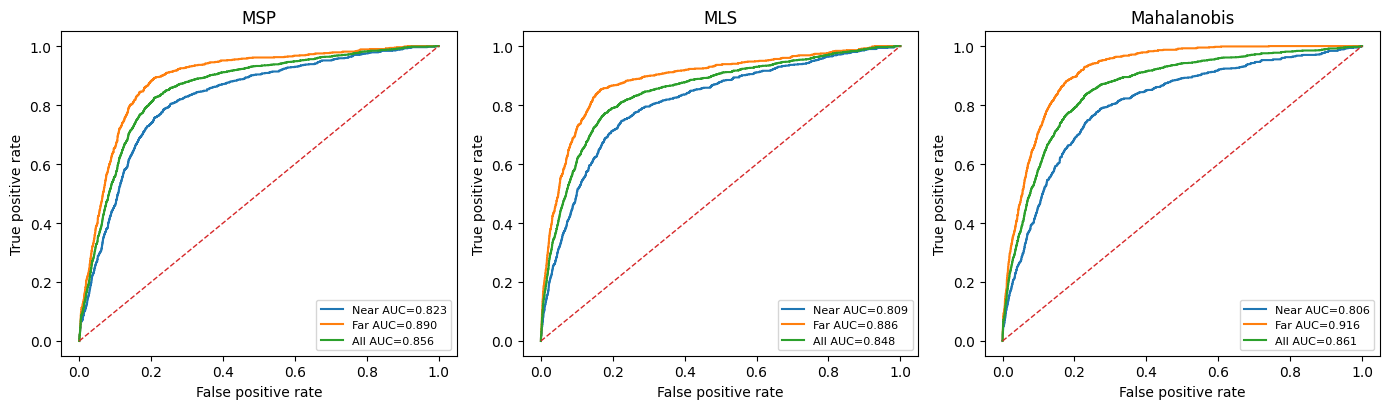

Saved: /content/drive/MyDrive/pa1-beyond-iid/task4/results/final_evaluation/figures/vanilla_msp_mls_mahalanobis_roc.png


In [9]:
#! MSP, MLS, and Mahalanobis: Known-vs-Near/Far/All
fig,axes=plt.subplots(1,3,figsize=(14,4.2))

for ax,name in zip(axes,['MSP','MLS','Mahalanobis']):
    k=vanilla_scores['known'][name]
    comps={'Near':vanilla_scores['near'][name],'Far':vanilla_scores['far'][name],'All':np.r_[vanilla_scores['near'][name],vanilla_scores['far'][name]]}

    for lab,u in comps.items():
        y=np.r_[np.zeros(len(k),dtype=int),np.ones(len(u),dtype=int)]; sc=np.r_[k,u]; fpr,tpr,_=roc_curve(y,sc)
        ax.plot(fpr,tpr,label=f'{lab} AUC={roc_auc_score(y,sc):.3f}')
    ax.plot([0,1],[0,1],linestyle='--',linewidth=1); ax.set_title(name); ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate'); ax.legend(fontsize=8)

fig.tight_layout(); p=FIG_DIR/'vanilla_msp_mls_mahalanobis_roc.png'; fig.savefig(p,dpi=180,bbox_inches='tight'); plt.show(); print('Saved:',p)


In [10]:
#! Which unknown classes are accepted, and which CIFAR-10 labels absorb them?
C10=known_test.classes; tau=VANILLA_TAU['MLS']

def breakdown(group,idx,scores,logits,names):
    pred=np.asarray(logits).argmax(1); out=[]

    for nm in names:
        cid=unknown_test.class_to_idx[nm]; pos=np.flatnonzero(fine_targets[idx]==cid); acc=scores[pos]<=tau; ap=pos[acc]
        if len(ap):
            c=np.bincount(pred[ap],minlength=10); j=int(np.argmax(c)); absorb=C10[j]; absorb_n=int(c[j])
        else: absorb=''; absorb_n=0
        out.append({'group':group,'unknown_class':nm,'count':int(len(pos)),'accepted_count':int(acc.sum()),'accepted_rate':float(acc.mean()),
                    'rejection_rate':float(1-acc.mean()),'most_common_absorbing_cifar10_class':absorb,'absorbing_count_among_accepted':absorb_n})
    return out

b=pd.DataFrame(breakdown('Near',near_idx,vanilla_scores['near']['MLS'],vanilla['near']['logits'],NEAR_CLASSES)+breakdown('Far',far_idx,vanilla_scores['far']['MLS'],vanilla['far']['logits'],FAR_CLASSES))
b.to_csv(FINAL_DIR/'vanilla_mls_unknown_class_breakdown.csv',index=False); display(b.round(4))


,group,unknown_class,count,accepted_count,accepted_rate,rejection_rate,most_common_absorbing_cifar10_class,absorbing_count_among_accepted
0,Near,bus,100,83,0.83,0.17,truck,66
1,Near,pickup_truck,100,89,0.89,0.11,automobile,57
2,Near,motorcycle,100,30,0.30,0.70,automobile,11
3,Near,tractor,100,56,0.56,0.44,truck,46
4,Near,wolf,100,82,0.82,0.18,cat,38
5,Near,fox,100,71,0.71,0.29,cat,38
6,Near,leopard,100,64,0.64,0.36,frog,30
7,Near,camel,100,58,0.58,0.42,deer,17
8,Far,bottle,100,36,0.36,0.64,ship,15
9,Far,bowl,100,47,0.47,0.53,cat,18


,group,rank,cifar100_test_index,unknown_class,predicted_cifar10_class,mls_unknownness,threshold,margin_below_threshold,interpretation_note
0,Near,1,5762,camel,bird,-12.117003,-6.010218,6.106785,
1,Near,2,959,fox,dog,-11.946433,-6.010218,5.936215,
2,Near,3,6339,bus,truck,-11.938823,-6.010218,5.928605,
3,Near,4,9231,wolf,cat,-11.913805,-6.010218,5.903587,
4,Near,5,7570,pickup_truck,truck,-10.694627,-6.010218,4.684409,
5,Far,1,1820,mushroom,frog,-11.025623,-6.010218,5.015405,
6,Far,2,3053,wardrobe,truck,-10.939103,-6.010218,4.928885,
7,Far,3,2797,bowl,cat,-10.938015,-6.010218,4.927797,
8,Far,4,5440,bottle,ship,-10.932432,-6.010218,4.922214,
9,Far,5,4785,sunflower,bird,-10.881164,-6.010218,4.870946,


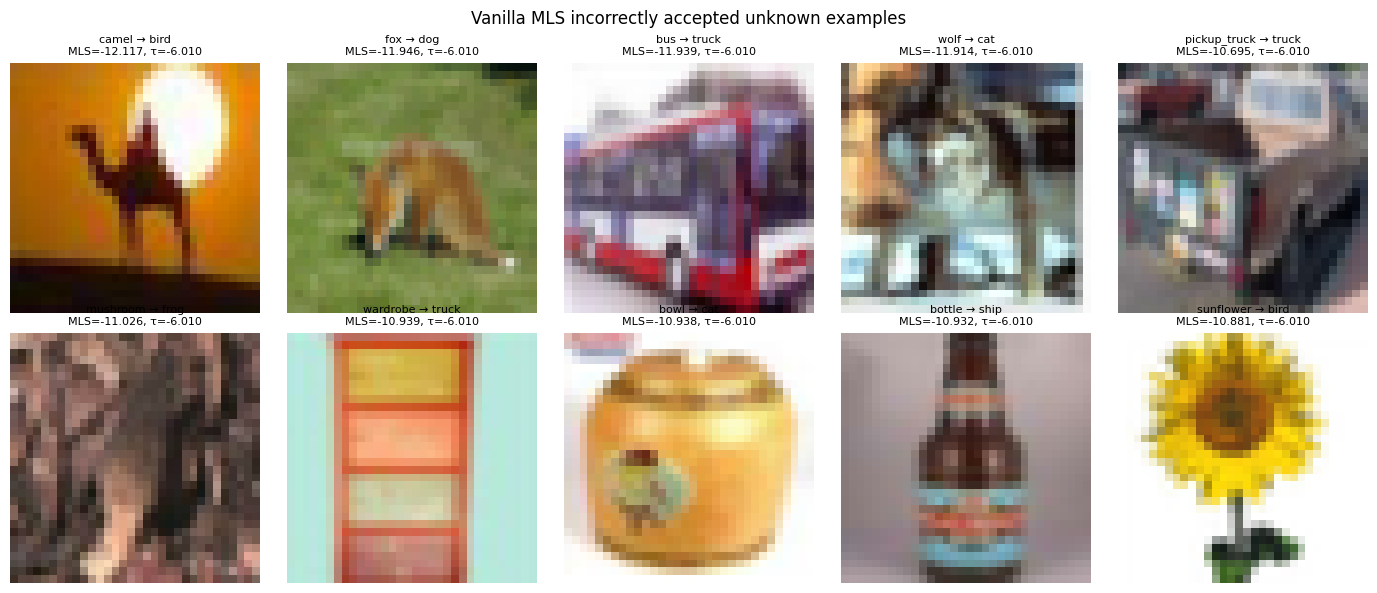

Saved: /content/drive/MyDrive/pa1-beyond-iid/task4/results/final_evaluation/figures/vanilla_mls_failure_examples.png


In [11]:
#! Save five per group; manually label each as semantically plausible or surprising in your report

def select_fail(group,idx,scores,logits,limit=5):
    accepted=np.flatnonzero(scores<=tau)

    if len(accepted)<3: raise RuntimeError(f'Fewer than 3 accepted {group} unknowns.')
    order=accepted[np.argsort(scores[accepted])]; chosen=[]; seen=set()

    for pos in order:
        g=int(idx[pos]); nm=unknown_test.classes[int(fine_targets[g])]
        if nm not in seen: chosen.append(int(pos)); seen.add(nm)
        if len(chosen)==limit: break

    for pos in order:
        if len(chosen)==limit: break
        if int(pos) not in chosen: chosen.append(int(pos))

    out=[]

    for rank,pos in enumerate(chosen,1):
        g=int(idx[pos]); pred=int(np.argmax(logits[pos])); nm=unknown_test.classes[int(fine_targets[g])]
        out.append({'group':group,'rank':rank,'cifar100_test_index':g,'unknown_class':nm,'predicted_cifar10_class':C10[pred],
                    'mls_unknownness':float(scores[pos]),'threshold':float(tau),'margin_below_threshold':float(tau-scores[pos]),'interpretation_note':''})
    return out

near_fail=select_fail('Near',near_idx,vanilla_scores['near']['MLS'],vanilla['near']['logits']); far_fail=select_fail('Far',far_idx,vanilla_scores['far']['MLS'],vanilla['far']['logits'])
fails=pd.DataFrame(near_fail+far_fail); fails.to_csv(FINAL_DIR/'vanilla_mls_failure_examples.csv',index=False); display(fails)

fig,axes=plt.subplots(2,5,figsize=(14,6))

for r,examples in enumerate([near_fail,far_fail]):
    for c,rec in enumerate(examples):
        ax=axes[r,c]; ax.imshow(unknown_test.data[rec['cifar100_test_index']]); ax.axis('off'); ax.set_title(f"{rec['unknown_class']} → {rec['predicted_cifar10_class']}\nMLS={rec['mls_unknownness']:.3f}, τ={rec['threshold']:.3f}",fontsize=8)

fig.suptitle('Vanilla MLS incorrectly accepted unknown examples'); fig.tight_layout(); fp=FIG_DIR/'vanilla_mls_failure_examples.png'; fig.savefig(fp,dpi=190,bbox_inches='tight'); plt.show(); print('Saved:',fp)


In [12]:
#! Machine-readable evidence + final immutability checks
p=FINAL_DIR/'final_predictions_and_scores.npz'; tmp=p.with_name(p.name+'.tmp')

with tmp.open('wb') as h:
    np.savez_compressed(h,cifar10_test_labels=labels,near_cifar100_indices=near_idx,far_cifar100_indices=far_idx,
        vanilla_known_logits=vanilla['known']['logits'],vanilla_near_logits=vanilla['near']['logits'],vanilla_far_logits=vanilla['far']['logits'],
        vanilla_known_msp=vanilla_scores['known']['MSP'],vanilla_near_msp=vanilla_scores['near']['MSP'],vanilla_far_msp=vanilla_scores['far']['MSP'],
        vanilla_known_mls=vanilla_scores['known']['MLS'],vanilla_near_mls=vanilla_scores['near']['MLS'],vanilla_far_mls=vanilla_scores['far']['MLS'],
        vanilla_known_energy=vanilla_scores['known']['Energy'],vanilla_near_energy=vanilla_scores['near']['Energy'],vanilla_far_energy=vanilla_scores['far']['Energy'],
        vanilla_known_mahalanobis=vanilla_scores['known']['Mahalanobis'],vanilla_near_mahalanobis=vanilla_scores['near']['Mahalanobis'],vanilla_far_mahalanobis=vanilla_scores['far']['Mahalanobis'],
        gcsc_known_logits=gcsc['known']['logits'],gcsc_near_logits=gcsc['near']['logits'],gcsc_far_logits=gcsc['far']['logits'],
        proser_known_logits=proser['known']['known_logits'],proser_near_logits=proser['near']['known_logits'],proser_far_logits=proser['far']['known_logits'],
        proser_known_dummy_logits=proser['known']['dummy_logits'],proser_near_dummy_logits=proser['near']['dummy_logits'],proser_far_dummy_logits=proser['far']['dummy_logits'],
        proser_known_placeholder=proser_placeholder['known'],proser_near_placeholder=proser_placeholder['near'],proser_far_placeholder=proser_placeholder['far'],
        vanilla_checkpoint_sha256=np.array(VANILLA_SHA),gcsc_checkpoint_sha256=np.array(GCSC_SHA),proser_checkpoint_sha256=np.array(PROSER_SHA))

os.replace(tmp,p)

need=[FINAL_DIR/'table1_vanilla_posthoc_scores.csv',FINAL_DIR/'table2_trained_model_comparison.csv',FINAL_DIR/'vanilla_score_spearman_unknowns.csv',
      FINAL_DIR/'vanilla_mls_unknown_class_breakdown.csv',FINAL_DIR/'vanilla_mls_failure_examples.csv',FIG_DIR/'vanilla_msp_mls_mahalanobis_roc.png',
      FIG_DIR/'vanilla_mls_failure_examples.png',p,FINAL_DIR/'fixed_cifar100_unknown_groups.json']

miss=[str(x) for x in need if not x.is_file()]

if miss: raise RuntimeError('Missing final evidence:\n'+'\n'.join(miss))
if len(pd.read_csv(FINAL_DIR/'table1_vanilla_posthoc_scores.csv'))!=4: raise RuntimeError('Table 1 row count wrong.')
if len(pd.read_csv(FINAL_DIR/'table2_trained_model_comparison.csv'))!=4: raise RuntimeError('Table 2 row count wrong.')
if sha256(VANILLA_BEST)!=VANILLA_SHA or sha256(GCSC_BEST)!=GCSC_SHA or sha256(PROSER_BEST)!=PROSER_SHA: raise RuntimeError('A checkpoint changed during evaluation.')

print('TASK 4E COMPLETE')
print('Task 4 required experiments + final evaluation are complete.')
print('Results:',FINAL_DIR)
print('For the report, manually annotate the failure CSV as semantically plausible vs surprising.')


TASK 4E COMPLETE
Task 4 required experiments + final evaluation are complete.
Results: /content/drive/MyDrive/pa1-beyond-iid/task4/results/final_evaluation
For the report, manually annotate the failure CSV as semantically plausible vs surprising.
